# **Practical Q1: Dimentionally reduction using PCA**

### Import Libraries

In [9]:
# Improting needed libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from PIL import Image



---


## Part (a)
### Receives the image path and desired output dimension from the user

In [10]:
image_name = input("Please enter the image address: ")
# add_image = sunflowers.jpg

# Load image with RGB colorset
img = Image.open(image_name).convert('RGB')
image_array = np.array(img)
H, W, C = image_array.shape

print("Image Address:", image_name)
print("Original Image Dimension:", image_array.shape)

Image Address: sunflowers.jpg
Original Image Dimension: (1080, 1920, 3)


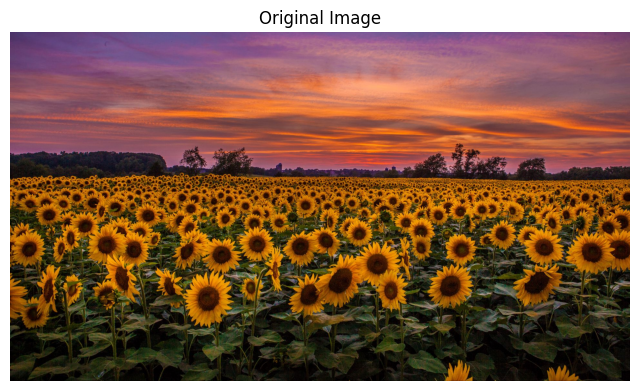

Maximum allowed dimensions for PCA is 1080.


In [19]:
plt.figure(figsize=(8,6))
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

# prepare reference channel Red for variance checking
reference_channel = image_array[:, :, 0]
flattened_ref = reference_channel.reshape(-1, W)

# maximum allowed components for PCA
max_components = min(flattened_ref.shape[0], flattened_ref.shape[1])  # min(H, W)
print(f"Maximum allowed dimensions for PCA is {max_components}.")



---


# Part B

### Check 95% variance condition (ask again if violated)


In [20]:
while True:
    desired_dims = int(input(f"Please enter the desired number of dimensions (1 to {max_components}): "))

    # ensure user doesn't request more than allowed
    if desired_dims < 1 or desired_dims > max_components:
        print(f"Invalid input. Please enter a value between 1 and {max_components}.\n")
        continue

    pca = PCA(n_components=desired_dims)
    pca.fit(flattened_ref)
    explained_variance = np.sum(pca.explained_variance_ratio_)

    if explained_variance < 0.95:
        print(f"Variance preserved: {explained_variance:.2%}")
        print("Variance is less than 95%. Please enter a larger number of dimensions.\n")
        # loop continues asking input again
    else:
        print(f"Variance preserved: {explained_variance:.2%}")
        break

Variance preserved: 93.00%
Variance is less than 95%. Please enter a larger number of dimensions.

Variance preserved: 94.25%
Variance is less than 95%. Please enter a larger number of dimensions.

Variance preserved: 95.19%


### Apply PCA to each RGB channel using the accepted desired_dims

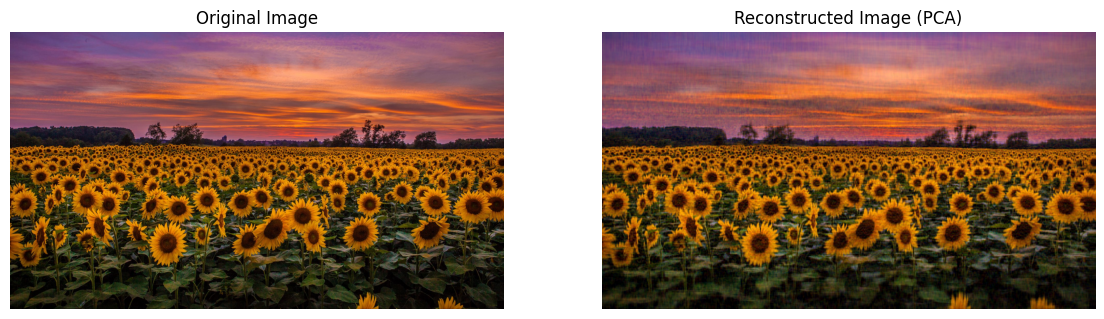

In [21]:
reconstructed_channels = []

for ch in range(C):
    channel_data = image_array[:, :, ch]
    flattened = channel_data.reshape(-1, W)

    pca = PCA(n_components=desired_dims)
    reduced = pca.fit_transform(flattened)
    reconstructed = pca.inverse_transform(reduced)
    reconstructed = reconstructed.reshape(H, W)

    reconstructed_channels.append(reconstructed)

# Combine channels
reconstructed_image = np.stack(reconstructed_channels, axis=2)
reconstructed_image = np.clip(reconstructed_image, 0, 255).astype(np.uint8)

# Display original and reconstructed images
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_array)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Reconstructed Image (PCA)")
plt.imshow(reconstructed_image)
plt.axis('off')

plt.show()



---

# Part C

### Cumulative explained variance plot

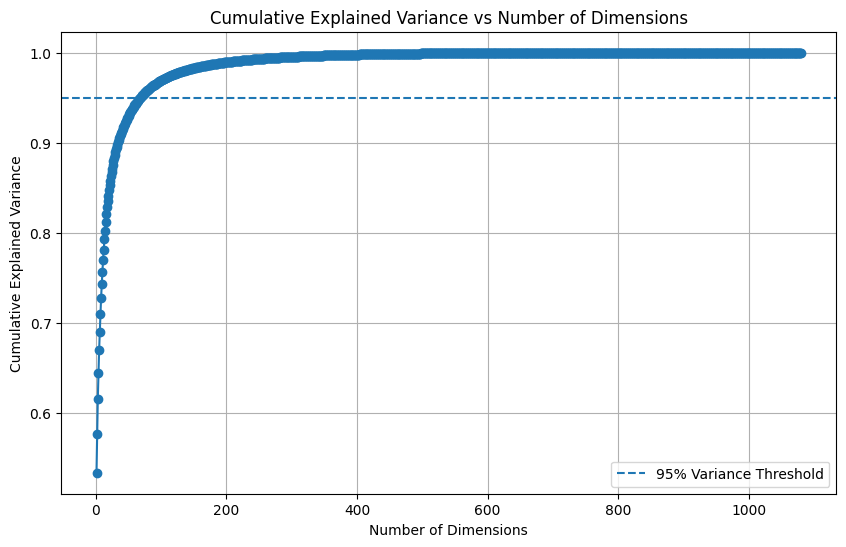

Required K: 68


In [18]:
# Dimentions will be limited to max_components

pca = PCA(n_components=None)
pca.fit(flattened_ref)

explained = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained)

dimensions = range(1, max_components + 1)

plt.figure(figsize=(10,6))
plt.plot(dimensions, cumulative_variance, marker='o')
plt.axhline(y=0.95, linestyle='--', label='95% Variance Threshold')
plt.xlabel('Number of Dimensions')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Dimensions')
plt.grid(True)
plt.legend()
plt.show()

required_k = int(np.searchsorted(np.array(cumulative_variance), 0.95) + 1)
print("Required K:",required_k)